In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob as glob
import re

from scipy.stats import mannwhitneyu

In [2]:
# Read in the files from the first classifier which was produced in early 2025
files = glob.glob('../data/2026_06_17_for_upload/*.csv')
files

['../data/2026_06_17_for_upload/P01_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P18_Prog_image_1.csv',
 '../data/2026_06_17_for_upload/P04_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P01_Day_0_image_2.csv',
 '../data/2026_06_17_for_upload/P04_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P18_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P03_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P28_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P08_Day_140_image_1.csv',
 '../data/2026_06_17_for_upload/P19_Day_0_image_2.csv',
 '../data/2026_06_17_for_upload/P05_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P18_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P19_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P03_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P17_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P02_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P08_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P07_D

In [3]:
# Create a dictionary which examines the expression of Ki67, PD1 and CD56 in each sample
cell_expression_dict = {}
cells = ['HSPC', 'CD4_T', 'CD8_T']
molecules = ['Ki67', 'CD56', 'PD-1']
for i in files:
    z = i.replace('../data/2026_06_17_for_upload/', '').replace('.csv', '')
    z = z.replace(' HH cell intensity 25102025_object_results', '')
    # Initialize nested dict for this sample
    cell_expression_dict[z] = {}
    
    a = pd.read_csv(i)
    a.columns = (a.columns
    .str.replace(' (Opal 540) Nucleus Intensity', '', regex=False)
    .str.replace(' (Opal 570) Cell Intensity', '', regex=False)
    .str.replace(' (Opal 620) Cell Intensity', '', regex=False)
)    
    for cell in cells:
        df = a.loc[a['2025_10_13_HH'] == cell, :]
        # Initialize dict for this cell type
        cell_expression_dict[z][cell] = {}
        
        for molecule in molecules:
            # Calculate and store mean
            mean_val = df.loc[:, molecule].mean()
            cell_expression_dict[z][cell][molecule] = mean_val
    
    
cell_expression_dict

{'P01_Day_0_image_1': {'HSPC': {'Ki67': 0.2531065496453901,
   'CD56': 2.245705024822695,
   'PD-1': 0.09742462056737589},
  'CD4_T': {'Ki67': 0.670571466367713,
   'CD56': 2.7431553452914796,
   'PD-1': 0.19330864798206276},
  'CD8_T': {'Ki67': 0.863924246018671,
   'CD56': 5.167810178473366,
   'PD-1': 0.29783720757825366}},
 'P18_Prog_image_1': {'HSPC': {'Ki67': 0.31089713176345074,
   'CD56': 1.322348949016918,
   'PD-1': 0.28546967527815875},
  'CD4_T': {'Ki67': 0.660736,
   'CD56': 1.8347099240924092,
   'PD-1': 0.4175804917491749},
  'CD8_T': {'Ki67': 0.7863295508166969,
   'CD56': 1.2585326760435573,
   'PD-1': 0.6693080753176044}},
 'P04_Day_0_image_1': {'HSPC': {'Ki67': 0.39240106856118373,
   'CD56': 2.221550475003091,
   'PD-1': 0.518011397848576},
  'CD4_T': {'Ki67': 1.859225315484159,
   'CD56': 2.473626426446527,
   'PD-1': 0.8112793272348652},
  'CD8_T': {'Ki67': 3.277836482800983,
   'CD56': 2.1090319110565114,
   'PD-1': 1.0208146896805896}},
 'P01_Day_0_image_2': {'H

In [4]:
# Create a df from the cell_expression_dict
df = pd.DataFrame.from_dict({(sample, cell): values 
                              for sample, cells in cell_expression_dict.items() 
                              for cell, values in cells.items()}, 
                             orient='index')

# Reset index to make sample and cell_type regular columns
df.index.names = ['sample', 'cell_type']
df = df.reset_index()

df['sample'] = df['sample'].str.replace('_image_2', '')
df['sample'] = df['sample'].str.replace('_image_1', '')

In [5]:
# Groupby images to account for samples where we had two images 
# at the same timepoint
df = df.groupby(['sample', 'cell_type']).mean().reset_index()
df.head()

,sample,cell_type,Ki67,CD56,PD-1
0,P01_Day_0,CD4_T,0.780947,1.748682,0.196086
1,P01_Day_0,CD8_T,0.874583,3.358231,0.247430
2,P01_Day_0,HSPC,0.518819,1.784817,0.139996
3,P01_Day_336,CD4_T,0.851955,2.728570,0.387133
4,P01_Day_336,CD8_T,1.187451,2.482557,0.415467


In [6]:
# Add timepoint information to the dataframe
tp_dict = {'0' : 'C1', '336' : 'C12', '168' : 'C7', '140' : 'C6', 'Prog' : 'Prog'}
df['pid'] = df['sample'].str.split('_').str[0]
df['tp'] = df['sample'].str.split('_').str[-1]
df['tp'] = df['tp'].map(tp_dict)

In [7]:
# Create dictionaries which detail the clinical outcome
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')

# Update the columns to a simpler name
cols_to_update = ['Outcome_C6_revised_Vid', 'Outcome_C12_CC486'] 
outcomes[cols_to_update] = outcomes[cols_to_update].replace({'non-responder_2': 'Non_responder', 'responder_1': 'Responder'}, regex=False)

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))
disease_dict = dict(zip(outcomes['PID'], outcomes['Diagnosis']))


In [8]:
# Add additional clinical information to the dataframe 
df['outcome6'] = df['pid'].map(outcomes_6)
df['outcome12'] = df['pid'].map(outcomes_12)
df['disease'] = df['pid'].map(disease_dict)
df

,sample,cell_type,Ki67,CD56,PD-1,pid,tp,outcome6,outcome12,disease
0,P01_Day_0,CD4_T,0.780947,1.748682,0.196086,P01,C1,Responder,Responder,MDS
1,P01_Day_0,CD8_T,0.874583,3.358231,0.247430,P01,C1,Responder,Responder,MDS
2,P01_Day_0,HSPC,0.518819,1.784817,0.139996,P01,C1,Responder,Responder,MDS
3,P01_Day_336,CD4_T,0.851955,2.728570,0.387133,P01,C12,Responder,Responder,MDS
4,P01_Day_336,CD8_T,1.187451,2.482557,0.415467,P01,C12,Responder,Responder,MDS
...,...,...,...,...,...,...,...,...,...,...
100,P25_Day_168,CD8_T,2.548466,4.248617,0.784817,P25,C7,Non_responder,NaN,AML
101,P25_Day_168,HSPC,1.129758,4.253782,0.393528,P25,C7,Non_responder,NaN,AML
102,P28_Day_0,CD4_T,0.443157,0.455334,0.110342,P28,C1,Non_responder,NaN,MDS
103,P28_Day_0,CD8_T,1.290433,0.948258,0.322203,P28,C1,Non_responder,NaN,MDS


In [9]:
# Filter out the samples which have few cells or a poor alignment
df = df.loc[df['sample'] != 'P08_Day_140', :] # This is an unusual timepoint 
df = df.loc[df['sample'] != 'P17_Day_168', :]  # The alignment of this sample was incorrect
df = df.loc[df['sample'] != 'P02_Day_0', :] # There are few cells 

In [10]:
df.head()

,sample,cell_type,Ki67,CD56,PD-1,pid,tp,outcome6,outcome12,disease
0,P01_Day_0,CD4_T,0.780947,1.748682,0.196086,P01,C1,Responder,Responder,MDS
1,P01_Day_0,CD8_T,0.874583,3.358231,0.247430,P01,C1,Responder,Responder,MDS
2,P01_Day_0,HSPC,0.518819,1.784817,0.139996,P01,C1,Responder,Responder,MDS
3,P01_Day_336,CD4_T,0.851955,2.728570,0.387133,P01,C12,Responder,Responder,MDS
4,P01_Day_336,CD8_T,1.187451,2.482557,0.415467,P01,C12,Responder,Responder,MDS


In [11]:
# Create a column which specifies whether a measurement was a response or a non-response
measurement = []
for x, y, z in zip(df['tp'], df['outcome6'], df['outcome12']):
    if x == 'C1':
        measurement.append('Diagnosis')
    elif (x == 'C7') & (y == 'Responder'):
        measurement.append('Response')
    elif (x == 'C7') & (y == 'Non_responder'):
        measurement.append('Non-response')
    elif x == 'Prog':
        measurement.append('Non-response')
    elif (x == 'C12') & (z == 'Responder'):
        measurement.append('Response')
    elif (x == 'C12') & (z == 'Non_responder'):
        measurement.append('Non-response')   
df['measurement'] = measurement      

In [12]:
# Add clinical information to aid plotting
pre_post_dict = {'C1' : 'pre', 'C12' : 'post', 'C7' : 'post', 'Prog' : 'post'}

df['tp1'] = df['tp'].map(pre_post_dict)
df['measurement'] = df['measurement'].replace('Response', 'Responder').replace('Non-response', 'Non_responder')

In [13]:
# Make a dictionary which specifies the expression comparisons to be made comparisons to be made 
dicts = {1 : {'HSPC' : 'Ki67', 'CD4_T' : 'Ki67', 'CD8_T' : 'Ki67'}, 2 : {'CD4_T' : 'PD-1', 'CD8_T' : 'PD-1'}}
dicts

{1: {'HSPC': 'Ki67', 'CD4_T': 'Ki67', 'CD8_T': 'Ki67'},
 2: {'CD4_T': 'PD-1', 'CD8_T': 'PD-1'}}

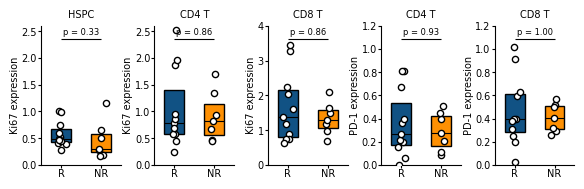

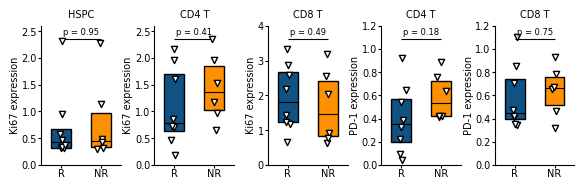

In [34]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
timepoints = ['pre', 'post']
outcomes = ['Responder', 'Non_responder']
colors = {'Responder': '#115284', 'Non_responder': '#fe9003'}
shape = {'pre': 'o', 'post': 'v'}

comparisons = [(key, cell_type, marker) for key, value in dicts.items() for cell_type, marker in value.items()]

ymax_dict = {
    1: {'HSPC': {'Ki67': 2.6}, 'CD4_T': {'Ki67': 2.6}, 'CD8_T': {'Ki67': 4}},
    2: {'CD4_T': {'PD-1': 1.2}, 'CD8_T': {'PD-1': 1.2}}
}

for row, timepoint in enumerate(timepoints):
    fig, axes = plt.subplots(nrows=1, ncols=len(comparisons), figsize=(5.7, 1.75))

    for col, (key, cell_type, marker) in enumerate(comparisons):
        ax = axes[col]
        values = []
        group_data = []

        for g_idx, outcome in enumerate(outcomes):
            if timepoint == 'pre':
                sub = df.loc[
                    (df['cell_type'] == cell_type) &
                    (df['tp1'] == timepoint) &
                    (df['outcome6'] == outcome),
                    marker
                ]
            elif timepoint == 'post':
                sub = df.loc[
                    (df['cell_type'] == cell_type) &
                    (df['tp1'] == timepoint) &
                    (df['measurement'] == outcome),
                    marker
                ]
            vals = sub.dropna().values
            values.append(vals)
            group_data.append(vals)

        # Draw boxplots for both groups at once
        bp = ax.boxplot(group_data, positions=[0, 1], widths=0.5,
                        patch_artist=True, showfliers=False)
        for patch, outcome in zip(bp['boxes'], outcomes):
            patch.set_facecolor(colors[outcome])
            patch.set_alpha(1.0)
        for element in ['whiskers', 'caps']:
            for item in bp[element]:
                item.set_linewidth(0)
        for item in bp['medians']:
            item.set_color('black')
            item.set_linewidth(0.8)

        # Add scatter points per group
        for g_idx, (outcome, vals) in enumerate(zip(outcomes, group_data)):
            ax.scatter(np.random.normal(g_idx, 0.05, size=len(vals)),
                       vals, color='white', marker=shape[timepoint],
                       edgecolor='black', s=20, zorder=3, alpha=1.0)

        # Mann-Whitney test
        if len(values[0]) > 0 and len(values[1]) > 0:
            stat, p = mannwhitneyu(values[0], values[1], alternative='two-sided')
            if p < 0.001:
                p_label = 'p < 0.001'
            elif p < 0.01:
                p_label = 'p < 0.01'
            elif p < 0.05:
                p_label = 'p < 0.05'
            else:
                p_label = f'p = {p:.2f}'

            # Use ymax if specified, otherwise use data max
            ymax = ymax_dict.get(key, {}).get(cell_type, {}).get(marker, None)
            y_top = ymax if ymax is not None else max(v.max() for v in values if len(v) > 0) * 1.2

            y_bracket = y_top * 0.88
            y_top_line = y_bracket * 1.03
            
            ax.plot([0, 1], [y_top_line, y_top_line],
                color='black', linewidth=0.8, solid_capstyle='butt')
            
            ax.text(0.5, y_bracket * 1.05, p_label,
                    ha='center', va='bottom', fontsize=6)

        # Set ylim after plotting so bracket fits within it
        ymax = ymax_dict.get(key, {}).get(cell_type, {}).get(marker, None)
        if ymax is not None:
            ax.set_ylim(bottom=0, top=ymax)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['R', 'NR'], fontsize=7)
        ax.tick_params(axis='both', labelsize=7, pad=1, length=2)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_title(f"{cell_type.replace('_', ' ')}", fontsize=7)
        ax.set_ylabel(f"{marker} expression", fontsize=7, labelpad=1)

    plt.tight_layout(pad=0.2)
    plt.savefig(f'../results/expression_{timepoint}.pdf', dpi=300, bbox_inches='tight')
    plt.show()